# Two-Stage CNN Training for Multi-object-classification in Rail-Crossing

This notebook implements best practice CNN training:
- **Stage 1**: Hyperparameter tuning with train/validation split (ALL LAYERS TRAINABLE)
- **Stage 2**: Final training on ALL training data (ALL LAYERS TRAINABLE)
- **Stage 3**: Evaluation on held-out test set

**Key Difference**: All model parameters are trainable from epoch 1 (no layer freezing)

## Data Structure Expected:
```
CNN-ready-dataset-2025-26/
├── train/
│   ├── class1/
│   └── class2/
└── test/
    ├── class1/
    └── class2/
```


## Setup: Mount Google Drive and Install Dependencies

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('✓ Google Drive mounted!')

Mounted at /content/drive
✓ Google Drive mounted!


In [2]:
# Install required packages
import subprocess
import sys

packages = ['torch', 'torchvision', 'scikit-learn', 'matplotlib', 'seaborn']

print('Installing dependencies...')
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print('✓ All dependencies installed!')

Installing dependencies...
✓ All dependencies installed!


## Imports

In [3]:
import os
import json
from pathlib import Path
from datetime import datetime
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('Using CPU')

PyTorch version: 2.11.0+cpu
CUDA available: False
Using CPU


## Configuration

In [4]:
# ============================================================
# CONFIGURATION - MODIFY AS NEEDED
# ============================================================

class Config:
    def __init__(self):
        # Device
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.seed = 42
        self.num_workers = 2  # Lower for Colab

        # Data paths
        self.data_root = '/content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Labeled-Data-NN/Journal-version-data/CNN-vehicle-type-labeled-dataset-80-20-split'  # CHANGE THIS
        self.save_dir = "/content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Outputs-2025-2026/Journal-outputs/CNN-vehicle-type"  # CHANGE THIS

        # Data
        self.batch_size = 32
        self.img_size = 224
        self.val_split = 0.2  # 20% of train for validation

        # Stage 1: Hyperparameter tuning
        self.stage1_epochs = 50
        self.stage1_lr = 1e-4
        self.stage1_patience = 5

        # Stage 2: Final training
        self.stage2_epochs = 20
        self.stage2_lr = 1e-5

        # Transforms
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

# Create config
config = Config()

print('Configuration:')
print(f'  Device: {config.device}')
print(f'  Data root: {config.data_root}')
print(f'  Save dir: {config.save_dir}')
print(f'  Batch size: {config.batch_size}')
print(f'  Stage 1 epochs: {config.stage1_epochs}')
print(f'  Stage 2 epochs: {config.stage2_epochs}')

# Create save directory
Path(config.save_dir).mkdir(parents=True, exist_ok=True)
print('\n✓ Configuration ready!')

Configuration:
  Device: cpu
  Data root: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Labeled-Data-NN/Journal-version-data/CNN-vehicle-type-labeled-dataset-80-20-split
  Save dir: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Outputs-2025-2026/Journal-outputs/CNN-vehicle-type
  Batch size: 32
  Stage 1 epochs: 50
  Stage 2 epochs: 20

✓ Configuration ready!


## Logger Class

In [5]:
class TrainingLogger:
    '''Logger for training progress'''
    def __init__(self, log_file):
        self.log_file = log_file
        self.messages = []

    def log(self, message, level='INFO'):
        formatted = f'[{level}] {message}'
        print(formatted)
        self.messages.append(formatted)

    def section(self, title):
        sep = '=' * 70
        self.log('')
        self.log(sep)
        self.log(f'  {title}')
        self.log(sep)

    def save_log(self):
        Path(self.log_file).parent.mkdir(parents=True, exist_ok=True)
        with open(self.log_file, 'w') as f:
            f.write('\n'.join(self.messages))
        self.log(f'\nLog saved to: {self.log_file}')


# Create logger
log_file = Path(config.save_dir) / f'training_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log'
logger = TrainingLogger(log_file)
logger.section('TWO-STAGE CNN TRAINING')
logger.log(f'Timestamp: {datetime.now()}')

[INFO] 
[INFO] ======================================================================
[INFO]   TWO-STAGE CNN TRAINING
[INFO] ======================================================================
[INFO] Timestamp: 2026-08-15 17:25:54.945494


## Data Loading Functions

In [6]:
def get_transforms(config):
    '''Get data augmentation transforms'''
    train_transform = transforms.Compose([
        transforms.Resize((config.img_size, config.img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        config.normalize,
    ])

    val_transform = transforms.Compose([
        transforms.Resize((config.img_size, config.img_size)),
        transforms.ToTensor(),
        config.normalize,
    ])

    return train_transform, val_transform


def load_data(train_dir, test_dir, config, logger):
    '''Load and split datasets'''
    logger.section('DATA LOADING')

    train_transform, val_transform = get_transforms(config)

    # Load datasets
    full_train = datasets.ImageFolder(train_dir, transform=train_transform)
    full_test = datasets.ImageFolder(test_dir, transform=val_transform)

    logger.log(f'✓ Loaded train folder: {len(full_train)} images')
    logger.log(f'✓ Loaded test folder: {len(full_test)} images')
    logger.log(f'✓ Classes: {', '.join(full_train.classes)}')

    # Split train into train/val
    labels = [full_train.samples[i][1] for i in range(len(full_train))]
    train_idx, val_idx = train_test_split(
        range(len(full_train)),
        test_size=config.val_split,
        stratify=labels,
        random_state=config.seed
    )

    logger.log(f'\nTrain/Val split (Stage 1):')
    logger.log(f'  Train: {len(train_idx)} images (80%)')
    logger.log(f'  Val:   {len(val_idx)} images (20%)')
    logger.log(f'  Test:  {len(full_test)} images (separate)')

    return full_train, full_test, train_idx, val_idx, train_transform, val_transform


print('✓ Data loading functions defined!')

✓ Data loading functions defined!


## Load Dataset

In [7]:
# Load data
train_dir = os.path.join(config.data_root, 'train')
test_dir = os.path.join(config.data_root, 'test')

full_train, full_test, train_idx, val_idx, train_transform, val_transform = load_data(
    train_dir, test_dir, config, logger
)

class_names = full_train.classes
num_classes = len(class_names)

print(f'\n✓ Dataset loaded! Classes: {class_names}')

[INFO] 
[INFO] ======================================================================
[INFO]   DATA LOADING
[INFO] ======================================================================
[INFO] ✓ Loaded train folder: 425 images
[INFO] ✓ Loaded test folder: 106 images
[INFO] ✓ Classes: bus, commercial-truck-van-and-service-vehicle, emergency-or-utility-vehicle, muti-class_vehicles, personal-commuter-vehicle
[INFO] 
Train/Val split (Stage 1):
[INFO]   Train: 340 images (80%)
[INFO]   Val:   85 images (20%)
[INFO]   Test:  106 images (separate)

✓ Dataset loaded! Classes: ['bus', 'commercial-truck-van-and-service-vehicle', 'emergency-or-utility-vehicle', 'muti-class_vehicles', 'personal-commuter-vehicle']


## Create DataLoaders

In [8]:
# Create datasets
train_dataset_s1 = Subset(full_train, train_idx)
val_dataset = Subset(full_train, val_idx)

# For Stage 2, need full train with transform
full_train_with_transform = datasets.ImageFolder(train_dir, transform=train_transform)

# Create dataloaders
train_loader_s1 = DataLoader(
    train_dataset_s1,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=True
)

full_train_loader = DataLoader(
    full_train_with_transform,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    full_test,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=True
)

print('✓ DataLoaders created!')
print(f'  Train (Stage 1): {len(train_loader_s1)} batches')
print(f'  Val (Stage 1): {len(val_loader)} batches')
print(f'  Full Train (Stage 2): {len(full_train_loader)} batches')
print(f'  Test (Stage 3): {len(test_loader)} batches')

✓ DataLoaders created!
  Train (Stage 1): 11 batches
  Val (Stage 1): 3 batches
  Full Train (Stage 2): 14 batches
  Test (Stage 3): 4 batches


## Create Model

In [9]:
def create_model_with_freezing(num_classes, config, logger, freeze_backbone=False):
    '''Create ResNet model with no layer freezing (all trainable from start)

    Args:
        num_classes: Number of output classes
        config: Configuration object
        logger: Logger object
        freeze_backbone: If True, freeze backbone (ALWAYS False for this version)
    '''
    logger.log(f'Creating ResNet50 model (pretrained=True)...')

    model = models.resnet50(pretrained=True)

    # All layers are trainable from the start (no freezing)
    logger.log('All layers will be trainable from epoch 1 (NO FREEZING)...')
    for param in model.parameters():
        param.requires_grad = True

    num_features = model.fc.in_features

    # Custom head for classification (always trainable)
    model.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, num_classes)
    )

    model = model.to(config.device)

    # Count trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())

    logger.log(f'✓ Model created')
    logger.log(f'  Total parameters: {total_params:,}')
    logger.log(f'  Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)')
    logger.log(f'  All layers trainable: YES')

    return model


model = create_model_with_freezing(num_classes, config, logger, freeze_backbone=False)
print('✓ Model created!')


[INFO] Creating ResNet50 model (pretrained=True)...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 70.9MB/s]


[INFO] All layers will be trainable from epoch 1 (NO FREEZING)...
[INFO] ✓ Model created
[INFO]   Total parameters: 24,623,429
[INFO]   Trainable parameters: 24,623,429 (100.0%)
[INFO]   All layers trainable: YES
✓ Model created!


## Training Functions

In [10]:
def train_epoch(model, train_loader, criterion, optimizer, config):
    '''Train one epoch'''
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(config.device)
        labels = labels.to(config.device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    avg_acc = correct / total

    return avg_loss, avg_acc


def validate_epoch(model, val_loader, criterion, config):
    '''Validate one epoch'''
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(config.device)
            labels = labels.to(config.device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(val_loader)
    avg_acc = correct / total

    return avg_loss, avg_acc


print('✓ Training functions defined!')

✓ Training functions defined!


## Trainer Class

In [11]:
class TwoStageTrainerWithFreezing:
    '''Two-stage training with all layers trainable from the start (no freezing)'''

    def __init__(self, model, config, save_dir, logger):
        self.model = model
        self.config = config
        self.save_dir = Path(save_dir)
        self.logger = logger

        self.criterion = nn.CrossEntropyLoss()

        self.history_stage1 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        self.history_stage2 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def print_trainable_layers(self):
        '''Print information about trainable layers'''
        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.model.parameters())

        self.logger.log(f'Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

        # Count by section
        conv_trainable = 0
        fc_trainable = 0
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                if 'fc' in name:
                    fc_trainable += param.numel()
                else:
                    conv_trainable += param.numel()

        self.logger.log(f'  Convolutional layers: {conv_trainable:,}')
        self.logger.log(f'  FC head layers: {fc_trainable:,}')

    def stage1_hyperparameter_tuning(self, train_loader, val_loader):
        '''Stage 1: Tune hyperparameters with all layers trainable'''
        self.logger.section('STAGE 1: HYPERPARAMETER TUNING (All Layers Trainable)')
        self.print_trainable_layers()

        # Optimize all parameters (nothing frozen)
        optimizer = optim.Adam(self.model.parameters(), lr=self.config.stage1_lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )

        best_val_loss = float('inf')
        patience_counter = 0

        for epoch in range(self.config.stage1_epochs):
            train_loss, train_acc = train_epoch(
                self.model, train_loader, self.criterion, optimizer, self.config
            )
            val_loss, val_acc = validate_epoch(
                self.model, val_loader, self.criterion, self.config
            )

            self.history_stage1['train_loss'].append(train_loss)
            self.history_stage1['val_loss'].append(val_loss)
            self.history_stage1['train_acc'].append(train_acc)
            self.history_stage1['val_acc'].append(val_acc)

            scheduler.step(val_loss)

            if (epoch + 1) % 5 == 0:
                self.logger.log(
                    f'Epoch {epoch+1}/{self.config.stage1_epochs} | '
                    f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
                    f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}'
                )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(
                    self.model.state_dict(),
                    self.save_dir / 'stage1_best_model.pth'
                )
                self.logger.log(f'  ✓ Best val loss: {val_loss:.4f}')
            else:
                patience_counter += 1

            if patience_counter >= self.config.stage1_patience:
                self.logger.log(f'Early stopping at epoch {epoch+1}')
                break

        self.logger.log(f'✓ Stage 1 complete!')
        return self.history_stage1

    def stage2_fine_tune_all(self, train_loader, val_loader):
        '''Stage 2: Continue training all layers on full dataset'''
        self.logger.section('STAGE 2: FULL TRAINING (All Layers Trainable)')

        # Load best model from stage 1
        self.model.load_state_dict(
            torch.load(self.save_dir / 'stage1_best_model.pth')
        )
        self.logger.log('✓ Loaded best model from Stage 1')

        self.print_trainable_layers()

        # Use lower learning rate for stage 2
        optimizer = optim.Adam(self.model.parameters(), lr=self.config.stage2_lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )

        best_val_loss = float('inf')
        patience_counter = 0

        for epoch in range(self.config.stage2_epochs):
            train_loss, train_acc = train_epoch(
                self.model, train_loader, self.criterion, optimizer, self.config
            )
            val_loss, val_acc = validate_epoch(
                self.model, val_loader, self.criterion, self.config
            )

            self.history_stage2['train_loss'].append(train_loss)
            self.history_stage2['val_loss'].append(val_loss)
            self.history_stage2['train_acc'].append(train_acc)
            self.history_stage2['val_acc'].append(val_acc)

            scheduler.step(val_loss)

            if (epoch + 1) % 5 == 0:
                self.logger.log(
                    f'Epoch {epoch+1}/{self.config.stage2_epochs} | '
                    f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
                    f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}'
                )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(
                    self.model.state_dict(),
                    self.save_dir / 'final_model.pth'
                )
                self.logger.log(f'  ✓ Best val loss: {val_loss:.4f}')
            else:
                patience_counter += 1

            if patience_counter >= self.config.stage1_patience:
                self.logger.log(f'Early stopping at epoch {epoch+1}')
                break

        self.logger.log('✓ Stage 2 complete!')
        self.logger.log(f'✓ Final model saved: {self.save_dir / "final_model.pth"}')

        return self.history_stage2

    def stage3_test_evaluation(self, test_loader):
        '''Stage 3: Evaluate on test set'''
        self.logger.section('STAGE 3: FINAL EVALUATION ON TEST SET')

        self.model.load_state_dict(
            torch.load(self.save_dir / 'final_model.pth')
        )
        self.model.eval()

        y_true, y_pred = [], []

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(self.config.device)
                outputs = self.model(images)
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.tolist())
                y_pred.extend(preds.cpu().tolist())

        accuracy = accuracy_score(y_true, y_pred)

        self.logger.log(f'\n✓ Test Accuracy: {accuracy:.4f}')
        self.logger.log('\nClassification Report:')
        report = classification_report(y_true, y_pred, target_names=class_names)
        self.logger.log(report)

        return y_true, y_pred, accuracy

    def plot_training_curves(self):
        '''Plot training curves for both stages'''
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        epochs1 = range(1, len(self.history_stage1['train_loss']) + 1)
        epochs2 = range(1, len(self.history_stage2['train_loss']) + 1)

        # Loss
        axes[0].plot(epochs1, self.history_stage1['train_loss'], label='Stage 1 Train', marker='o')
        axes[0].plot(epochs1, self.history_stage1['val_loss'], label='Stage 1 Val', marker='s')
        axes[0].plot([max(epochs1) + i for i in epochs2], self.history_stage2['train_loss'],
                    label='Stage 2 Train', marker='^')
        axes[0].plot([max(epochs1) + i for i in epochs2], self.history_stage2['val_loss'],
                    label='Stage 2 Val', marker='d')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Loss (All Layers Trainable from Epoch 1)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy
        axes[1].plot(epochs1, self.history_stage1['train_acc'], label='Stage 1 Train', marker='o')
        axes[1].plot(epochs1, self.history_stage1['val_acc'], label='Stage 1 Val', marker='s')
        axes[1].plot([max(epochs1) + i for i in epochs2], self.history_stage2['train_acc'],
                    label='Stage 2 Train', marker='^')
        axes[1].plot([max(epochs1) + i for i in epochs2], self.history_stage2['val_acc'],
                    label='Stage 2 Val', marker='d')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Training Accuracy (All Layers Trainable from Epoch 1)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plot_file = self.save_dir / 'training_curves_no_freezing.png'
        plt.savefig(plot_file, dpi=150, bbox_inches='tight')
        self.logger.log(f'\n✓ Training curves saved: {plot_file}')
        plt.show()



## STAGE 1: Hyperparameter Tuning

In [12]:
# Create trainer
trainer = TwoStageTrainerWithFreezing(model, config, config.save_dir, logger)

# Run Stage 1
history1 = trainer.stage1_hyperparameter_tuning(train_loader_s1, val_loader)

[INFO] 
[INFO] ======================================================================
[INFO]   STAGE 1: HYPERPARAMETER TUNING (All Layers Trainable)
[INFO] ======================================================================
[INFO] Trainable parameters: 24,623,429 / 24,623,429 (100.0%)
[INFO]   Convolutional layers: 23,508,032
[INFO]   FC head layers: 1,115,397


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[INFO]   ✓ Best val loss: 1.4127
[INFO]   ✓ Best val loss: 1.1859
[INFO]   ✓ Best val loss: 0.9702
[INFO]   ✓ Best val loss: 0.8855
[INFO] Epoch 5/50 | Train Loss: 0.6861 | Val Loss: 0.7884 | Train Acc: 0.7765 | Val Acc: 0.7412
[INFO]   ✓ Best val loss: 0.7884
[INFO]   ✓ Best val loss: 0.6595
[INFO]   ✓ Best val loss: 0.5786
[INFO] Epoch 10/50 | Train Loss: 0.2703 | Val Loss: 0.6309 | Train Acc: 0.8941 | Val Acc: 0.8000
[INFO] Early stopping at epoch 13
[INFO] ✓ Stage 1 complete!


## STAGE 2: Final Training on All Data

In [13]:
# Run Stage 2
history2 = trainer.stage2_fine_tune_all(full_train_loader, val_loader)

[INFO] 
[INFO] ======================================================================
[INFO]   STAGE 2: FULL TRAINING (All Layers Trainable)
[INFO] ======================================================================
[INFO] ✓ Loaded best model from Stage 1
[INFO] Trainable parameters: 24,623,429 / 24,623,429 (100.0%)
[INFO]   Convolutional layers: 23,508,032
[INFO]   FC head layers: 1,115,397
[INFO]   ✓ Best val loss: 0.5072
[INFO]   ✓ Best val loss: 0.4656
[INFO]   ✓ Best val loss: 0.4118
[INFO] Epoch 5/20 | Train Loss: 0.3556 | Val Loss: 0.3738 | Train Acc: 0.8776 | Val Acc: 0.9294
[INFO]   ✓ Best val loss: 0.3738
[INFO]   ✓ Best val loss: 0.3154
[INFO]   ✓ Best val loss: 0.3013
[INFO] Epoch 10/20 | Train Loss: 0.2570 | Val Loss: 0.3026 | Train Acc: 0.9082 | Val Acc: 0.8824
[INFO]   ✓ Best val loss: 0.2403
[INFO]   ✓ Best val loss: 0.2202
[INFO] Epoch 15/20 | Train Loss: 0.1764 | Val Loss: 0.1812 | Train Acc: 0.9576 | Val Acc: 0.9647
[INFO]   ✓ Best val loss: 0.1812
[INFO]   ✓ Best

## STAGE 3: Test Evaluation

In [14]:
# Run Stage 3
y_true, y_pred, test_accuracy = trainer.stage3_test_evaluation(test_loader)

[INFO] 
[INFO] ======================================================================
[INFO]   STAGE 3: FINAL EVALUATION ON TEST SET
[INFO] ======================================================================
[INFO] 
✓ Test Accuracy: 0.7075
[INFO] 
Classification Report:
[INFO]                                           precision    recall  f1-score   support

                                     bus       0.88      1.00      0.94        15
commercial-truck-van-and-service-vehicle       0.68      0.77      0.72        30
            emergency-or-utility-vehicle       0.50      0.44      0.47        16
                     muti-class_vehicles       0.85      0.46      0.59        24
               personal-commuter-vehicle       0.68      0.90      0.78        21

                                accuracy                           0.71       106
                               macro avg       0.72      0.71      0.70       106
                            weighted avg       0.72      0.71

## Generate Training Curves

[INFO] 
✓ Training curves saved: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Outputs-2025-2026/Journal-outputs/CNN-vehicle-type/training_curves_no_freezing.png


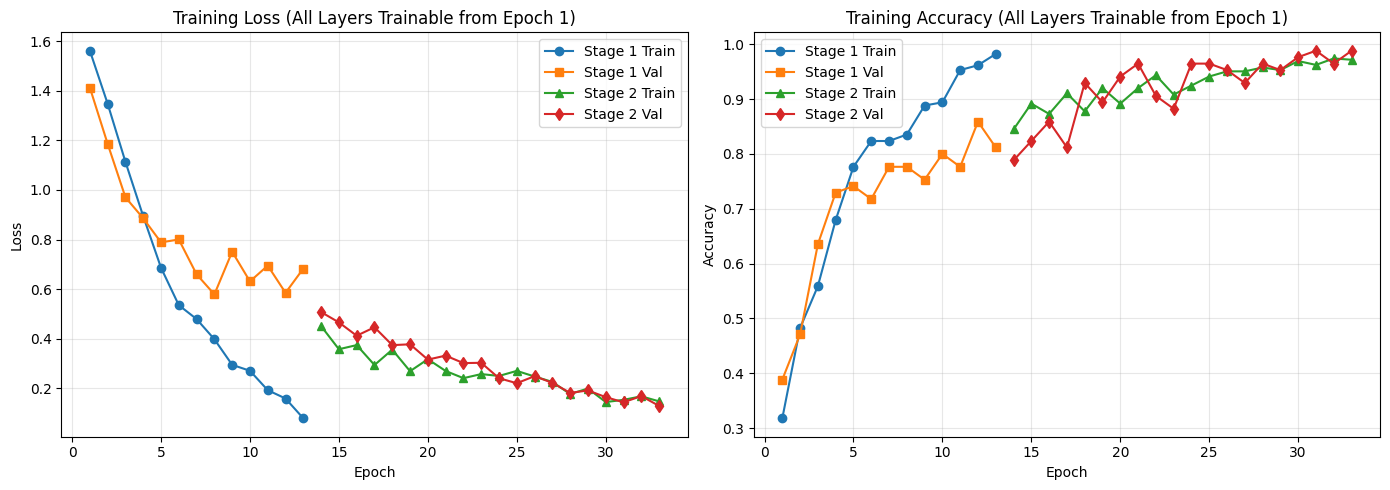

In [15]:
# Plot training curves
trainer.plot_training_curves()

## Confusion Matrix

✓ Confusion matrix saved: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Outputs-2025-2026/Journal-outputs/CNN-vehicle-type/confusion_matrix.png


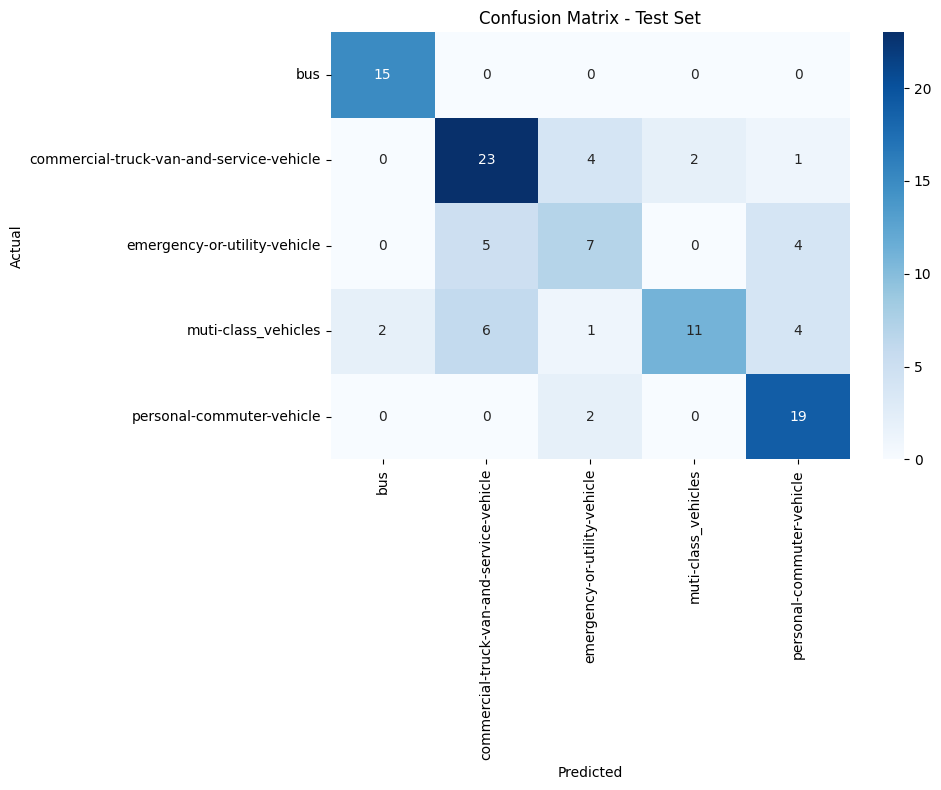

In [16]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

# Save
cm_file = Path(config.save_dir) / 'confusion_matrix.png'
plt.savefig(cm_file, dpi=150, bbox_inches='tight')
print(f'✓ Confusion matrix saved: {cm_file}')
plt.show()

## Training Complete!

In [17]:
logger.section('TRAINING COMPLETE')
logger.log(f'✓ All results saved to: {config.save_dir}')
logger.log(f'✓ Final model: {Path(config.save_dir) / "final_model.pth"}')
logger.log(f'✓ Test Accuracy: {test_accuracy:.4f}')
logger.log(f'✓ Confusion matrix: {Path(config.save_dir) / "confusion_matrix.png"}')
logger.log(f'✓ Training curves: {Path(config.save_dir) / "training_curves.png"}')
logger.log(f'✓ Log file: {log_file}')

# Save log
logger.save_log()

print('\n' + '='*70)
print('✓ TWO-STAGE TRAINING COMPLETE!')
print('='*70)
print(f'\nFinal Model Location:')
print(f'  {Path(config.save_dir) / "final_model.pth"}')
print(f'\nTest Accuracy: {test_accuracy:.2%}')
print(f'\nAll files saved to: {config.save_dir}')
print('='*70)

[INFO] 
[INFO] ======================================================================
[INFO]   TRAINING COMPLETE
[INFO] ======================================================================
[INFO] ✓ All results saved to: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Outputs-2025-2026/Journal-outputs/CNN-vehicle-type
[INFO] ✓ Final model: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Outputs-2025-2026/Journal-outputs/CNN-vehicle-type/final_model.pth
[INFO] ✓ Test Accuracy: 0.7075
[INFO] ✓ Confusion matrix: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Outputs-2025-2026/Journal-outputs/CNN-vehicle-type/confusion_matrix.png
[INFO] ✓ Training curves: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Outputs-2025-2026/Journal-outputs/CNN-vehicle-type/training_curves.png
[INFO] ✓ Log file: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Outputs-2025-2026/Journal-outputs/CNN-vehicle-type/training_20260815_172554.l

## Visulize Predictions on Test dataset

In [18]:
## Evaluate Functions
def evaluate(loader, model, device):
    y_true, y_pred, images_seen = [], [], []
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.tolist())
            y_pred.extend(preds.cpu().tolist())
            images_seen.extend(images.cpu())
    return y_true, y_pred, images_seen


def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)  # ✓ FIXED
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)   # ✓ FIXED
    return (img_tensor * std + mean).clamp(0, 1)


# Load model
model_path = Path(config.save_dir) / "final_model.pth"
model.load_state_dict(torch.load(model_path))  # ✓ FIXED
print(f"✅ Loaded model from: {model_path}")

# Get predictions (IMPORTANT: Call evaluate first!)
y_true, y_pred, images_seen = evaluate(test_loader, model, config.device)  # ✓ FIXED
print(f"✅ Got {len(y_true)} predictions")

# === VISUALIZE SAMPLE PREDICTIONS ===
from math import ceil

num_images = min(25, len(images_seen))
cols = 5
rows = ceil(num_images / cols)

fig = plt.figure(figsize=(3 * cols, 3.5 * rows))

for i in range(num_images):
    ax = fig.add_subplot(rows, cols, i + 1)

    # Unnormalize and display
    img_display = unnormalize(images_seen[i]).permute(1, 2, 0)
    ax.imshow(img_display)

    # Get predictions
    pred = y_pred[i]
    true = y_true[i]

    # Color code: green if correct, red if wrong
    color = "green" if pred == true else "red"

    ax.set_title(
        f"Pred: {class_names[pred]}\nTrue: {class_names[true]}",
        color=color,
        fontsize=10,
        fontweight='bold' if pred != true else 'normal'
    )
    ax.axis('off')

fig.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save
save_path = Path(config.save_dir) / 'sample_predictions.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✅ Saved to: {save_path}")

plt.show()

Output hidden; open in https://colab.research.google.com to view.


CONFIDENCE SCORE STATISTICS (TEST SET)
Mean Confidence:       0.8178
Median Confidence:     0.8977
Std Dev:               0.1912
Min Confidence:        0.3606
Max Confidence:        0.9996

Confidence by Class:
  bus: 0.9368 (n=15)
  commercial-truck-van-and-service-vehicle: 0.8737 (n=30)
  emergency-or-utility-vehicle: 0.7674 (n=16)
  muti-class_vehicles: 0.6718 (n=24)
  personal-commuter-vehicle: 0.8583 (n=21)



/tmp/ipykernel_2360/4204321047.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(confidence_data, labels=class_labels, patch_artist=True)


✅ Confidence score chart saved to: /content/drive/MyDrive/Railroad-crossing-Vision-Language-Model/Outputs-2025-2026/Journal-outputs/CNN-vehicle-type/confidence_scores_analysis.png


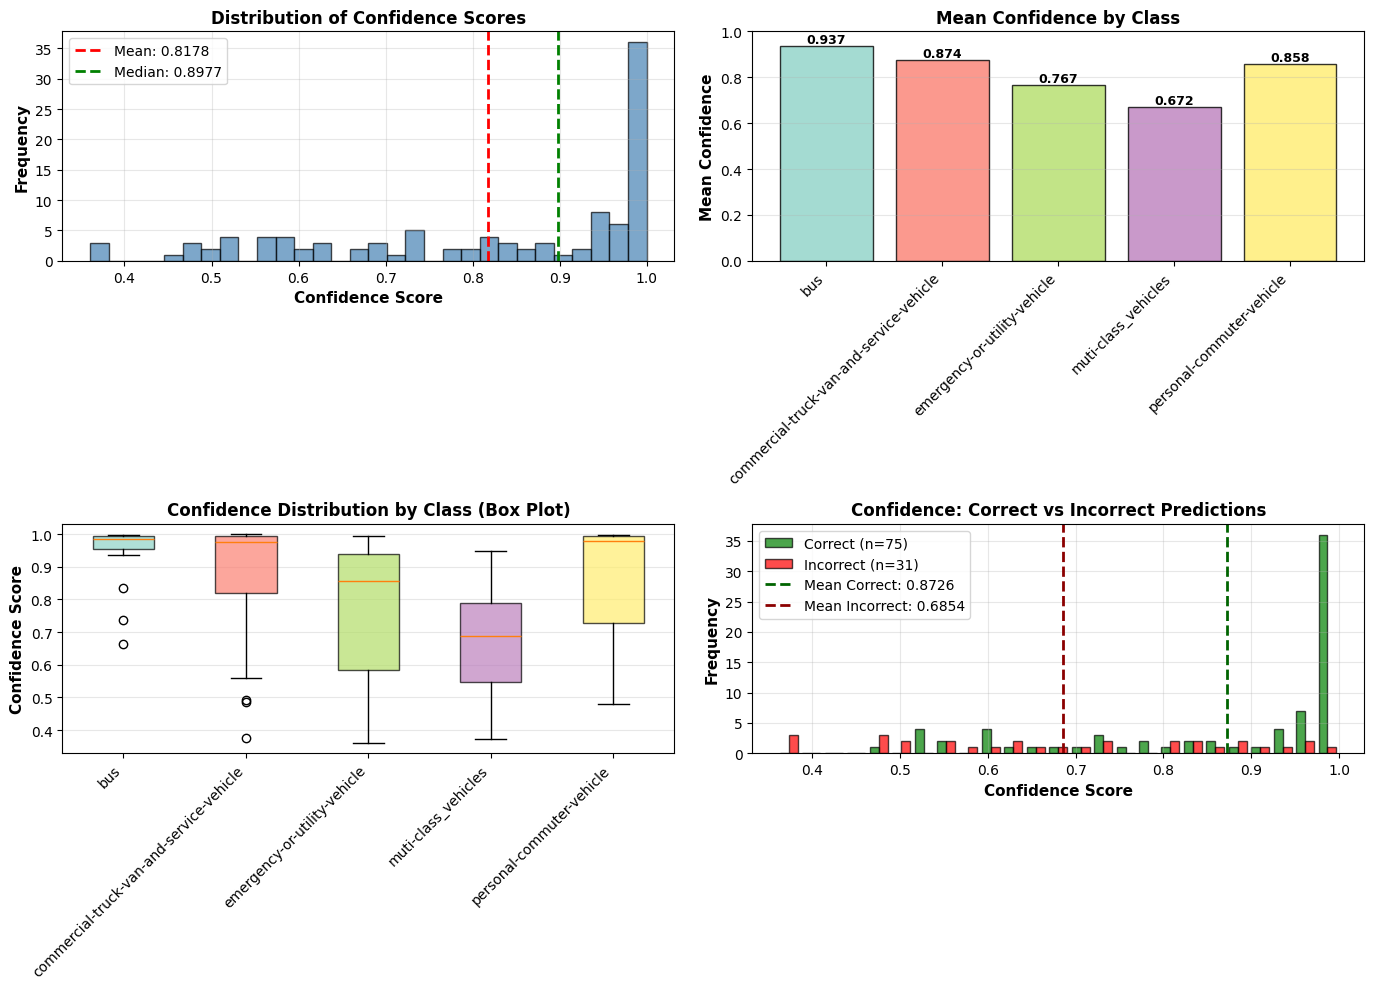

In [19]:
# ============================================================
# CONFIDENCE SCORE ANALYSIS ON TEST DATASET
# ============================================================

def evaluate_with_confidence(loader, model, device):
    """Enhanced evaluate function that captures confidence scores"""
    y_true, y_pred, confidences = [], [], []
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            # Get probabilities
            probabilities = torch.softmax(outputs, dim=1)

            # Get max probability (confidence) and predicted class
            max_probs, preds = torch.max(probabilities, 1)

            y_true.extend(labels.tolist())
            y_pred.extend(preds.cpu().tolist())
            confidences.extend(max_probs.cpu().tolist())

    return y_true, y_pred, confidences


# Get predictions WITH confidence scores
y_true, y_pred, confidences = evaluate_with_confidence(test_loader, model, config.device)

# === COMPUTE STATISTICS ===
mean_confidence = np.mean(confidences)
median_confidence = np.median(confidences)
min_confidence = np.min(confidences)
max_confidence = np.max(confidences)
std_confidence = np.std(confidences)

# Confidence by class
confidence_by_class = {}
for class_idx in range(len(class_names)):
    class_mask = np.array(y_true) == class_idx
    if class_mask.any():
        confidence_by_class[class_names[class_idx]] = {
            'mean': np.mean(np.array(confidences)[class_mask]),
            'count': class_mask.sum()
        }

print("\n" + "="*70)
print("CONFIDENCE SCORE STATISTICS (TEST SET)")
print("="*70)
print(f"Mean Confidence:       {mean_confidence:.4f}")
print(f"Median Confidence:     {median_confidence:.4f}")
print(f"Std Dev:               {std_confidence:.4f}")
print(f"Min Confidence:        {min_confidence:.4f}")
print(f"Max Confidence:        {max_confidence:.4f}")
print("\nConfidence by Class:")
for class_name, stats in confidence_by_class.items():
    print(f"  {class_name}: {stats['mean']:.4f} (n={stats['count']})")
print("="*70 + "\n")


# === CREATE VISUALIZATIONS ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of confidence scores
ax1 = axes[0, 0]
ax1.hist(confidences, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(mean_confidence, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_confidence:.4f}')
ax1.axvline(median_confidence, color='green', linestyle='--', linewidth=2, label=f'Median: {median_confidence:.4f}')
ax1.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Confidence Scores', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Confidence by class (bar chart)
ax2 = axes[0, 1]
class_names_list = list(confidence_by_class.keys())
mean_confs = [confidence_by_class[cn]['mean'] for cn in class_names_list]
colors_bar = plt.cm.Set3(np.linspace(0, 1, len(class_names_list)))
bars = ax2.bar(range(len(class_names_list)), mean_confs, color=colors_bar, edgecolor='black', alpha=0.8)
ax2.set_xticks(range(len(class_names_list)))
ax2.set_xticklabels(class_names_list, rotation=45, ha='right')
ax2.set_ylabel('Mean Confidence', fontsize=11, fontweight='bold')
ax2.set_title('Mean Confidence by Class', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, conf in zip(bars, mean_confs):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{conf:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Confidence distribution by class (box plot)
ax3 = axes[1, 0]
confidence_data = []
class_labels = []
for class_idx, class_name in enumerate(class_names):
    class_mask = np.array(y_true) == class_idx
    if class_mask.any():
        confidence_data.append(np.array(confidences)[class_mask])
        class_labels.append(class_name)

bp = ax3.boxplot(confidence_data, labels=class_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('Confidence Score', fontsize=11, fontweight='bold')
ax3.set_title('Confidence Distribution by Class (Box Plot)', fontsize=12, fontweight='bold')
ax3.set_xticklabels(class_labels, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# 4. Correct vs Incorrect predictions confidence
ax4 = axes[1, 1]
correct_mask = np.array(y_true) == np.array(y_pred)
correct_confidences = np.array(confidences)[correct_mask]
incorrect_confidences = np.array(confidences)[~correct_mask]

ax4.hist([correct_confidences, incorrect_confidences], bins=25,
         label=[f'Correct (n={len(correct_confidences)})', f'Incorrect (n={len(incorrect_confidences)})'],
         color=['green', 'red'], alpha=0.7, edgecolor='black')
ax4.axvline(np.mean(correct_confidences), color='darkgreen', linestyle='--', linewidth=2,
            label=f'Mean Correct: {np.mean(correct_confidences):.4f}')
ax4.axvline(np.mean(incorrect_confidences), color='darkred', linestyle='--', linewidth=2,
            label=f'Mean Incorrect: {np.mean(incorrect_confidences):.4f}')
ax4.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax4.set_title('Confidence: Correct vs Incorrect Predictions', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()

# Save figure
confidence_chart_path = Path(config.save_dir) / 'confidence_scores_analysis.png'
plt.savefig(confidence_chart_path, dpi=150, bbox_inches='tight')
print(f"✅ Confidence score chart saved to: {confidence_chart_path}")

plt.show()

## Using the Trained Model for Inference

In [20]:
def inference_on_image(image_path, model, config, class_names):
    '''Run inference on a single image'''
    from PIL import Image

    transform = transforms.Compose([
        transforms.Resize((config.img_size, config.img_size)),
        transforms.ToTensor(),
        config.normalize,
    ])

    # Load and prepare image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(config.device)

    # Inference
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        prediction = torch.argmax(outputs, dim=1)

    pred_class = class_names[prediction.item()]
    pred_confidence = probabilities[0, prediction.item()].item()

    return {
        'predicted_class': pred_class,
        'confidence': pred_confidence,
        'all_probabilities': {cn: prob.item() for cn, prob in zip(class_names, probabilities[0])}
    }


print('✓ Inference function ready!')
print('\nUsage:')
print('  result = inference_on_image("path/to/image.jpg", model, config, class_names)')
print('  print(result)')

✓ Inference function ready!

Usage:
  result = inference_on_image("path/to/image.jpg", model, config, class_names)
  print(result)


## Important Notes

### Before Running:
1. **Change data paths in Configuration cell:**
   - `config.data_root` → path to your `CNN-ready-dataset-2025-26` folder
   - `config.save_dir` → where to save results

### Training Times (on Google Colab GPU):
- Stage 1: 15-20 minutes (with early stopping)
- Stage 2: 5-10 minutes
- Stage 3: 1-2 minutes
- **Total: ~25-35 minutes**

### Expected Results:
- Train Accuracy: 85-95%
- Validation Accuracy (Stage 1): 82-90%
- Test Accuracy (Stage 3): 85-92%

### Output Files:
- `final_model.pth` - Your trained model
- `training_curves.png` - Loss and accuracy plots
- `confusion_matrix.png` - Confusion matrix visualization
- `training_*.log` - Detailed training log

### For Deployment:
Download `final_model.pth` and use the inference example above!